In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")


In [16]:

data = pd.read_csv('data (1).csv')




In [17]:
print(data.isnull().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [18]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [19]:
y = data['diagnosis'].values
x_data = data.drop(['diagnosis'], axis=1)

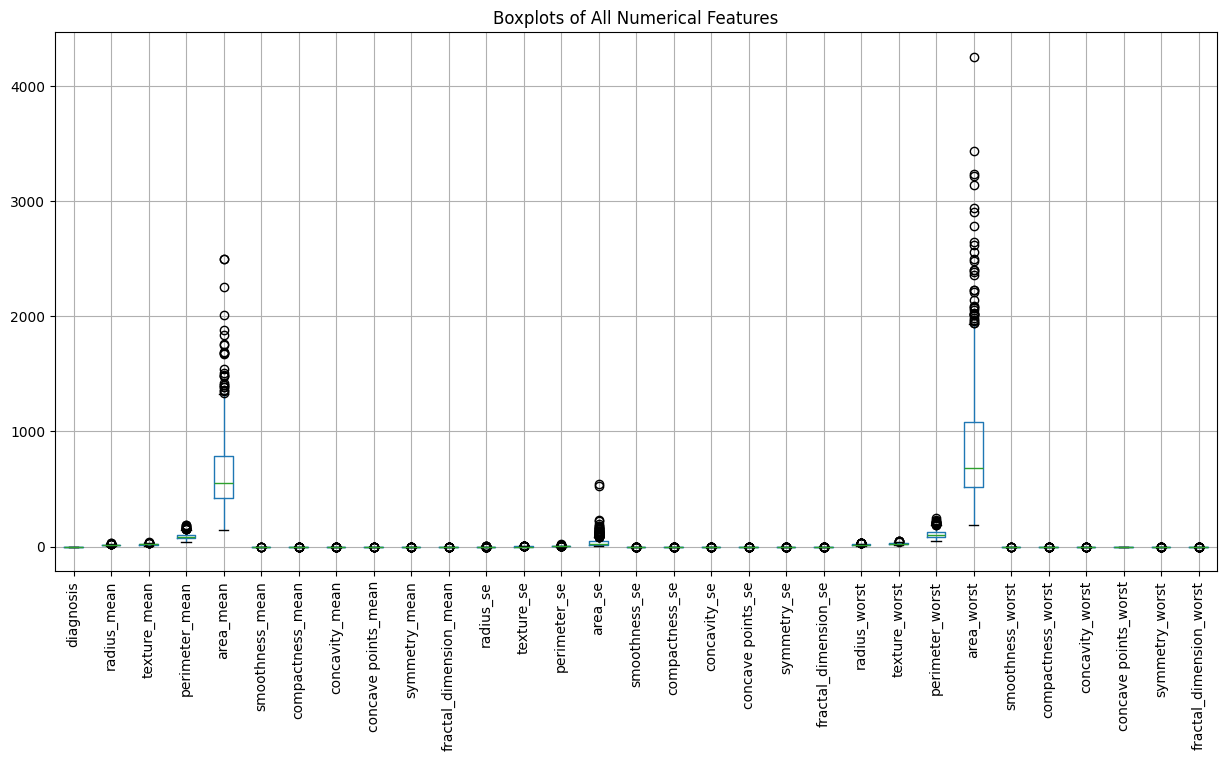

In [20]:
plt.figure(figsize=(15, 7))
data.boxplot()
plt.title("Boxplots of All Numerical Features")
plt.xticks(rotation=90)
plt.show()

Columns chosen for selective standardization: ['area_mean', 'perimeter_mean', 'area_worst', 'perimeter_worst']

 Standardization applied ONLY to selected outlier-heavy columns.



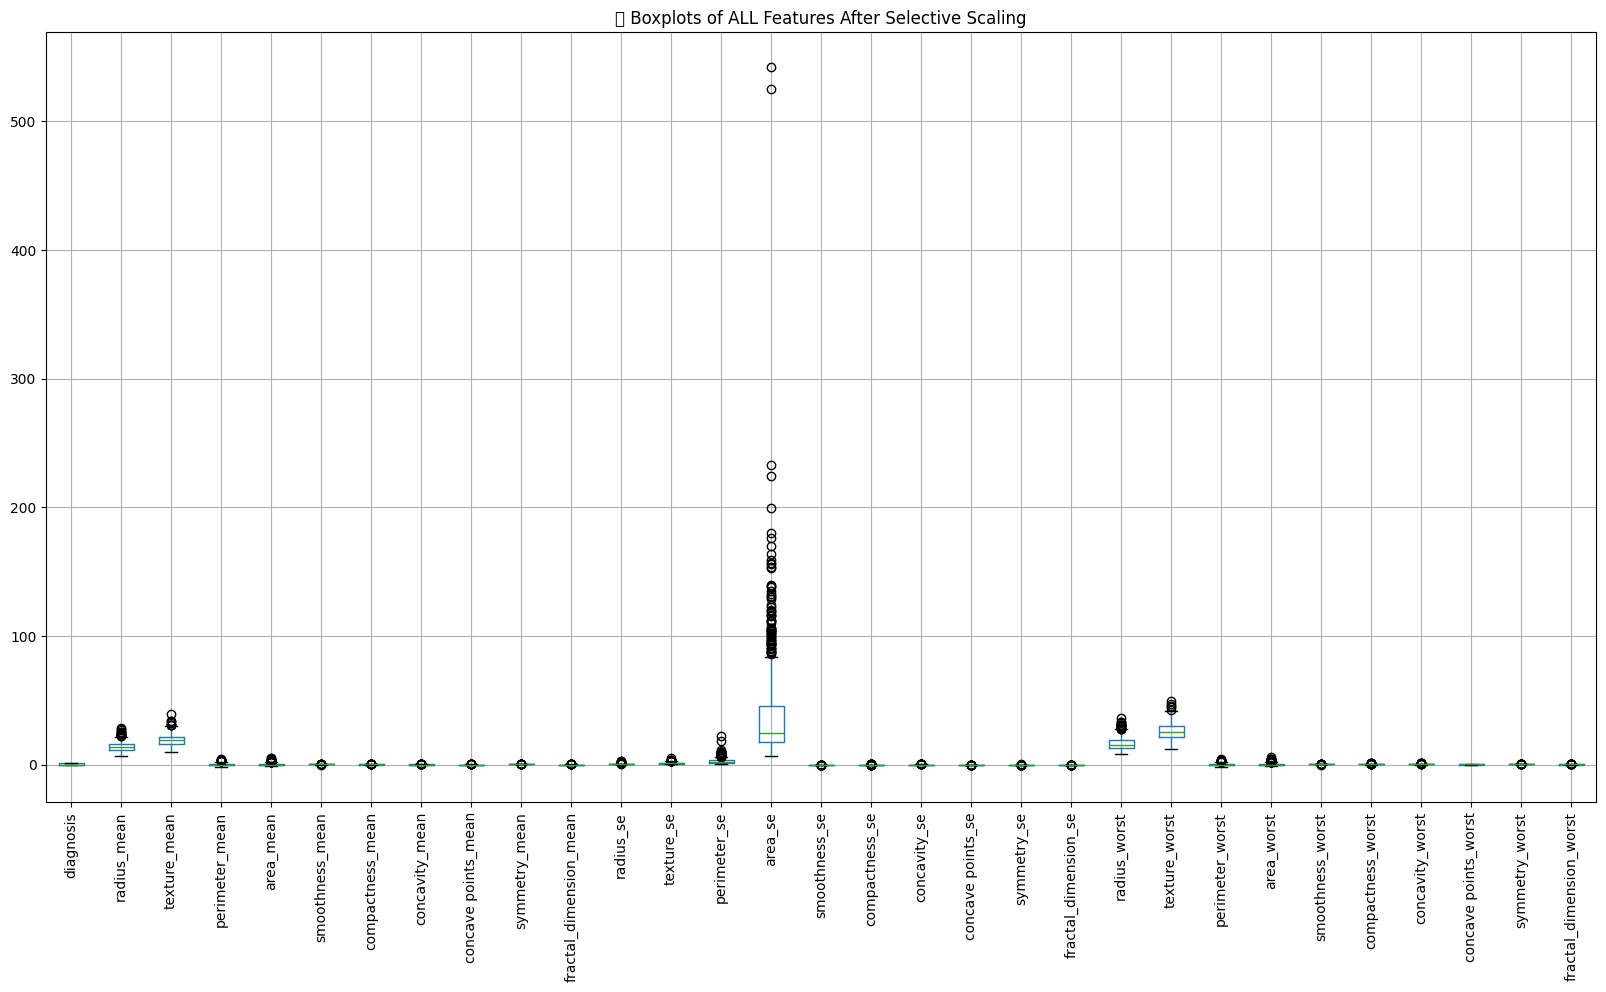

In [21]:
outlier_columns = [
    'area_mean',
    'perimeter_mean',
    'area_worst',
    'perimeter_worst'
]

print("Columns chosen for selective standardization:", outlier_columns)


scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[outlier_columns] = scaler.fit_transform(data[outlier_columns])
print("\n Standardization applied ONLY to selected outlier-heavy columns.\n")


plt.figure(figsize=(20, 10))
data_scaled.boxplot()
plt.title("📉 Boxplots of ALL Features After Selective Scaling")
plt.xticks(rotation=90)
plt.show()

In [22]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


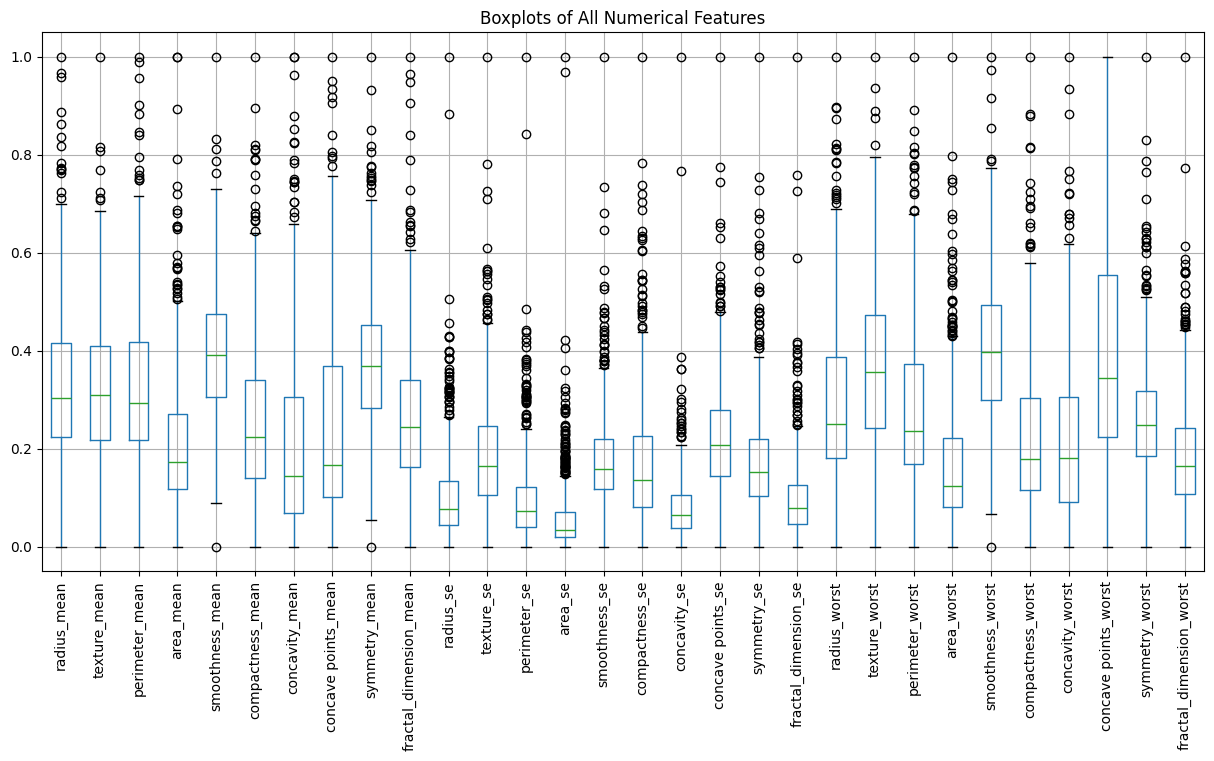

In [23]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split


train_data, temp_data = train_test_split(
    data_scaled, test_size=0.7, random_state=42, stratify=data_scaled['diagnosis']
)
test1_data, test2_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['diagnosis']
)

print(f"Train: {train_data.shape}, Test1: {test1_data.shape}, Test2: {test2_data.shape}")

X_train = train_data.drop('diagnosis', axis=1).values
y_train = train_data['diagnosis'].values.reshape(-1,1)
X_test1 = test1_data.drop('diagnosis', axis=1).values
y_test1 = test1_data['diagnosis'].values.reshape(-1,1)
X_test2 = test2_data.drop('diagnosis', axis=1).values
y_test2 = test2_data['diagnosis'].values.reshape(-1,1)


X_train_bias = np.c_[np.ones((X_train.shape[0],1)), X_train]
X_test1_bias = np.c_[np.ones((X_test1.shape[0],1)), X_test1]
X_test2_bias = np.c_[np.ones((X_test2.shape[0],1)), X_test2]


Train: (170, 31), Test1: (199, 31), Test2: (200, 31)


In [25]:
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [28]:
y_pred_train = dt_model.predict(X_train)
y_pred_test1 = dt_model.predict(X_test1)
y_pred_test2 = dt_model.predict(X_test2)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def evaluate_model(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\n {dataset_name} Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    return acc, prec, rec, f1

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign (0)", "Malignant (1)"])
    disp.plot(cmap="Blues", values_format='d')
    plt.title(title)
    plt.show()





📘 Train Data Metrics:
Accuracy : 0.9765
Precision: 0.9836
Recall   : 0.9524
F1-Score : 0.9677


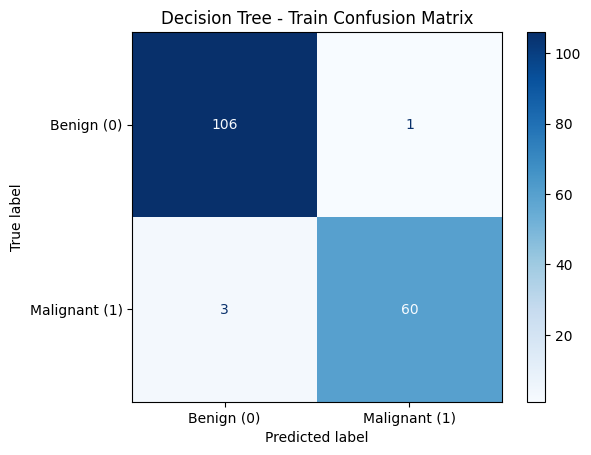

In [47]:
dt_train = evaluate_model(y_train, y_pred_train, "Train Data")
plot_conf_matrix(y_train, y_pred_train, "Decision Tree - Train Confusion Matrix")




📘 Test1 Data Metrics:
Accuracy : 0.9146
Precision: 0.8904
Recall   : 0.8784
F1-Score : 0.8844


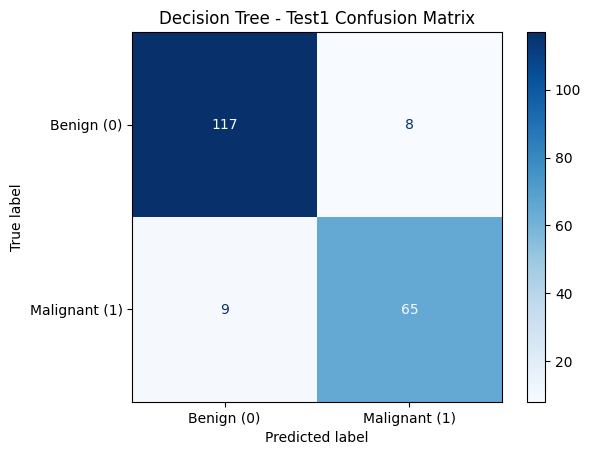

In [48]:
dt_test1 = evaluate_model(y_test1, y_pred_test1, "Test1 Data")
plot_conf_matrix(y_test1, y_pred_test1, "Decision Tree - Test1 Confusion Matrix")



📘 Test2 Data Metrics:
Accuracy : 0.8900
Precision: 0.8354
Recall   : 0.8800
F1-Score : 0.8571


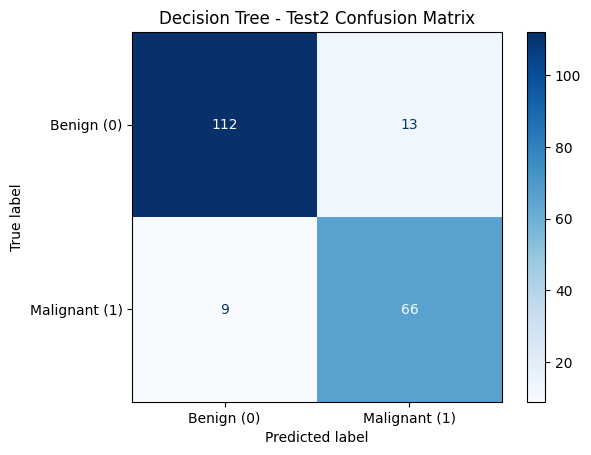

In [49]:
dt_test2 = evaluate_model(y_test2, y_pred_test2, "Test2 Data")
plot_conf_matrix(y_test2, y_pred_test2, "Decision Tree - Test2 Confusion Matrix")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")


print(" Performing GridSearchCV for Decision Tree...")

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("\n Best Parameters Found by GridSearchCV:", best_params)

🔍 Performing GridSearchCV for Decision Tree...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

 Best Parameters Found by GridSearchCV: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}


In [36]:
best_dt = DecisionTreeClassifier(**best_params, random_state=42)
best_dt.fit(X_train, y_train)

y_pred_train = best_dt.predict(X_train)
y_pred_test1 = best_dt.predict(X_test1)
y_pred_test2 = best_dt.predict(X_test2)

In [37]:
def evaluate_model(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\n📘 {dataset_name} Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    return acc, prec, rec, f1



def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap="Blues", values_format='d')
    plt.title(title)
    plt.show()





📘 Training Data Metrics:
Accuracy : 0.9765
Precision: 0.9836
Recall   : 0.9524
F1-Score : 0.9677


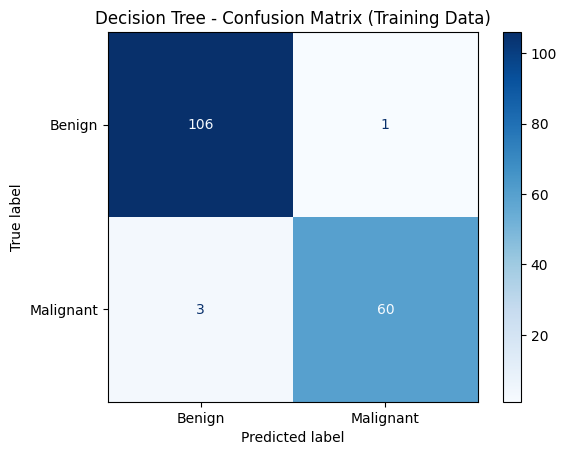

In [38]:
train_metrics = evaluate_model(y_train, y_pred_train, "Training Data")
plot_conf_matrix(y_train, y_pred_train, "Decision Tree - Confusion Matrix (Training Data)")


📘 Test1 Data Metrics:
Accuracy : 0.9146
Precision: 0.8904
Recall   : 0.8784
F1-Score : 0.8844


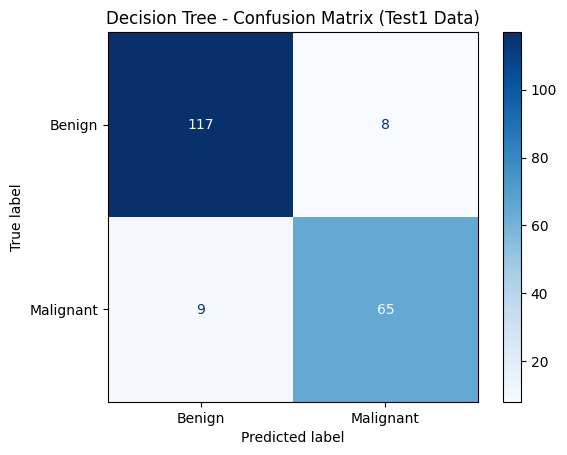

In [39]:
test1_metrics = evaluate_model(y_test1, y_pred_test1, "Test1 Data")
plot_conf_matrix(y_test1, y_pred_test1, "Decision Tree - Confusion Matrix (Test1 Data)")


📘 Test2 Data Metrics:
Accuracy : 0.8900
Precision: 0.8354
Recall   : 0.8800
F1-Score : 0.8571


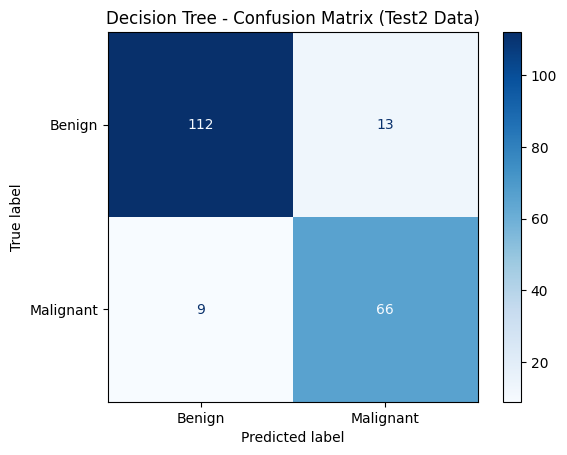

In [40]:
test2_metrics = evaluate_model(y_test2, y_pred_test2, "Test2 Data")
plot_conf_matrix(y_test2, y_pred_test2, "Decision Tree - Confusion Matrix (Test2 Data)")

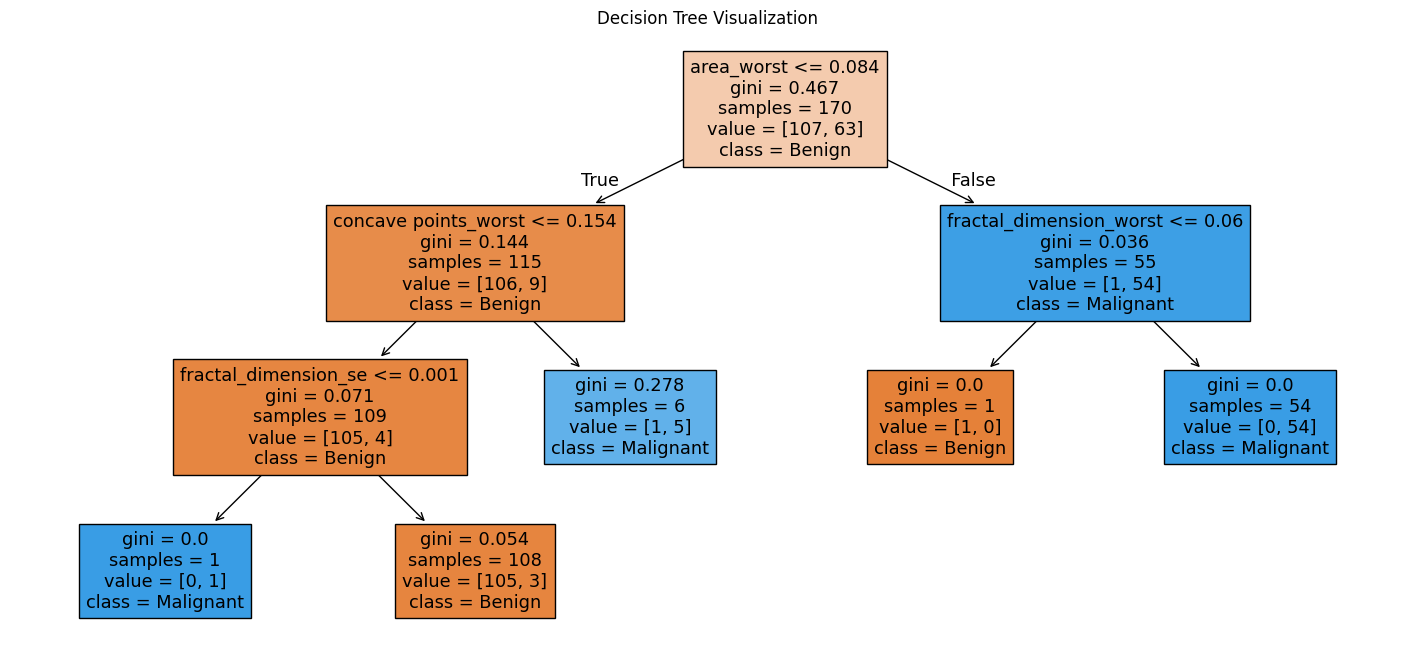

In [41]:
plt.figure(figsize=(18, 8))
plot_tree(best_dt, filled=True,
          feature_names=train_data.drop('diagnosis', axis=1).columns,
          class_names=['Benign', 'Malignant'])
plt.title("Decision Tree Visualization")
plt.show()

In [42]:
print("\n Training Ensemble Models using Tuned Decision Tree Parameters...\n")


bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(**best_params, random_state=42),
    n_estimators=50,
    random_state=42
)
bag_model.fit(X_train, y_train.ravel())
bag_pred_train = bag_model.predict(X_train)
bag_pred_test1 = bag_model.predict(X_test1)
bag_pred_test2 = bag_model.predict(X_test2)


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    criterion=best_params['criterion'],
    random_state=42
)
rf_model.fit(X_train, y_train.ravel())
rf_pred_train = rf_model.predict(X_train)
rf_pred_test1 = rf_model.predict(X_test1)
rf_pred_test2 = rf_model.predict(X_test2)


xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=best_params['max_depth'] if best_params['max_depth'] else 4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train.ravel())
xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test1 = xgb_model.predict(X_test1)
xgb_pred_test2 = xgb_model.predict(X_test2)


 Training Ensemble Models using Tuned Decision Tree Parameters...



In [43]:
def evaluate_all_models(model_name, y_train, pred_train, y_test1, pred_test1, y_test2, pred_test2):
    train_m = evaluate_model(y_train, pred_train, f"{model_name} (Train)")
    test1_m = evaluate_model(y_test1, pred_test1, f"{model_name} (Test1)")
    test2_m = evaluate_model(y_test2, pred_test2, f"{model_name} (Test2)")
    return {
        "Model": model_name,
        "Train_Accuracy": train_m[0],
        "Test1_Accuracy": test1_m[0],
        "Test2_Accuracy": test2_m[0],
        "Train_Recall": train_m[2],
        "Test1_Recall": test1_m[2],
        "Test2_Recall": test2_m[2],
        "Train_F1": train_m[3],
        "Test1_F1": test1_m[3],
        "Test2_F1": test2_m[3],
    }

results = []
results.append(evaluate_all_models("Decision Tree", y_train, y_pred_train, y_test1, y_pred_test1, y_test2, y_pred_test2))
results.append(evaluate_all_models("Bagging", y_train, bag_pred_train, y_test1, bag_pred_test1, y_test2, bag_pred_test2))
results.append(evaluate_all_models("Random Forest", y_train, rf_pred_train, y_test1, rf_pred_test1, y_test2, rf_pred_test2))
results.append(evaluate_all_models("XGBoost", y_train, xgb_pred_train, y_test1, xgb_pred_test1, y_test2, xgb_pred_test2))

results_df = pd.DataFrame(results)
print("\n Full Model Performance Summary (Train / Test1 / Test2):\n")
results_df


📘 Decision Tree (Train) Metrics:
Accuracy : 0.9765
Precision: 0.9836
Recall   : 0.9524
F1-Score : 0.9677

📘 Decision Tree (Test1) Metrics:
Accuracy : 0.9146
Precision: 0.8904
Recall   : 0.8784
F1-Score : 0.8844

📘 Decision Tree (Test2) Metrics:
Accuracy : 0.8900
Precision: 0.8354
Recall   : 0.8800
F1-Score : 0.8571

📘 Bagging (Train) Metrics:
Accuracy : 0.9706
Precision: 0.9833
Recall   : 0.9365
F1-Score : 0.9593

📘 Bagging (Test1) Metrics:
Accuracy : 0.9698
Precision: 0.9722
Recall   : 0.9459
F1-Score : 0.9589

📘 Bagging (Test2) Metrics:
Accuracy : 0.9350
Precision: 0.9429
Recall   : 0.8800
F1-Score : 0.9103

📘 Random Forest (Train) Metrics:
Accuracy : 0.9706
Precision: 0.9833
Recall   : 0.9365
F1-Score : 0.9593

📘 Random Forest (Test1) Metrics:
Accuracy : 0.9598
Precision: 0.9853
Recall   : 0.9054
F1-Score : 0.9437

📘 Random Forest (Test2) Metrics:
Accuracy : 0.9300
Precision: 0.9420
Recall   : 0.8667
F1-Score : 0.9028

📘 XGBoost (Train) Metrics:
Accuracy : 1.0000
Precision: 1.0000


,Model,Train_Accuracy,Test1_Accuracy,Test2_Accuracy,Train_Recall,Test1_Recall,Test2_Recall,Train_F1,Test1_F1,Test2_F1
0,Decision Tree,0.976471,0.914573,0.890,0.952381,0.878378,0.880000,0.967742,0.884354,0.857143
1,Bagging,0.970588,0.969849,0.935,0.936508,0.945946,0.880000,0.959350,0.958904,0.910345
2,Random Forest,0.970588,0.959799,0.930,0.936508,0.905405,0.866667,0.959350,0.943662,0.902778
3,XGBoost,1.000000,0.989950,0.950,1.000000,0.972973,0.906667,1.000000,0.986301,0.931507



📊 Confusion Matrices for Decision Tree:


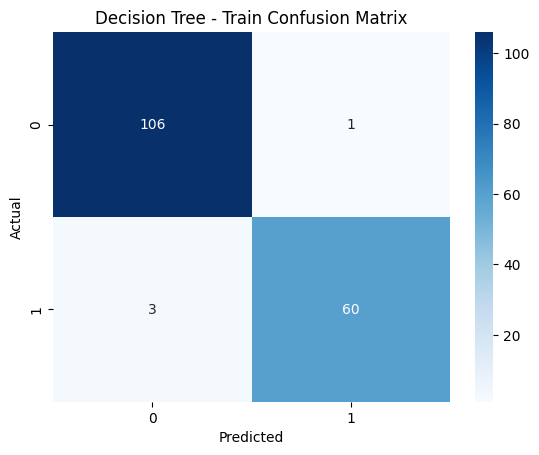

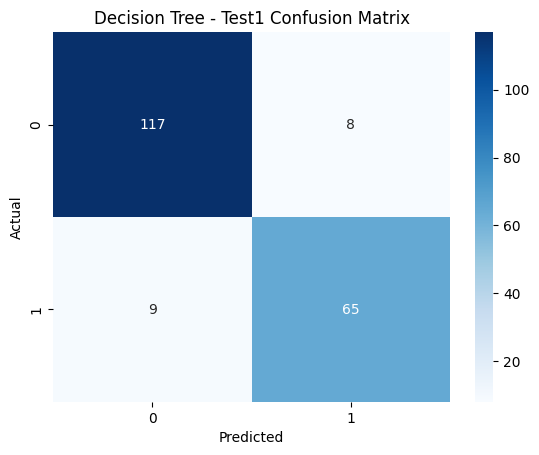

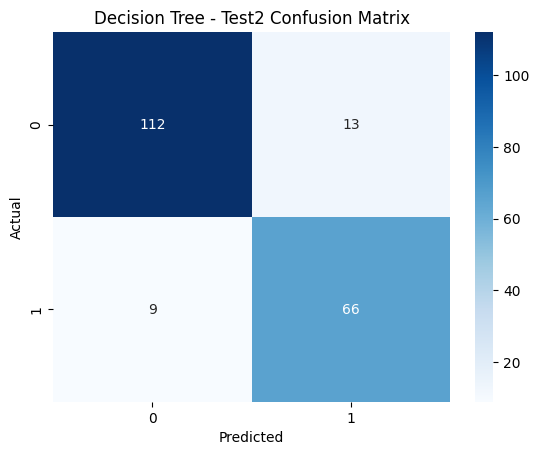


📊 Confusion Matrices for Bagging:


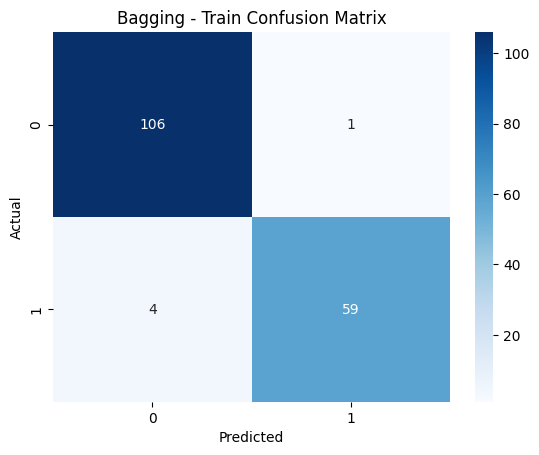

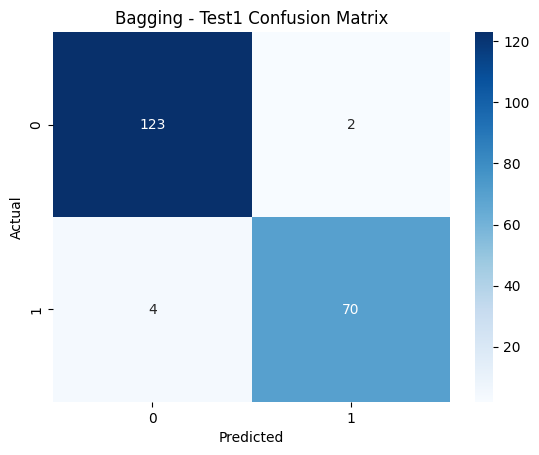

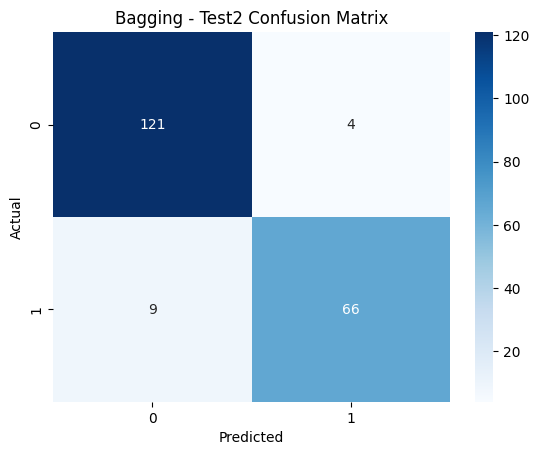


📊 Confusion Matrices for Random Forest:


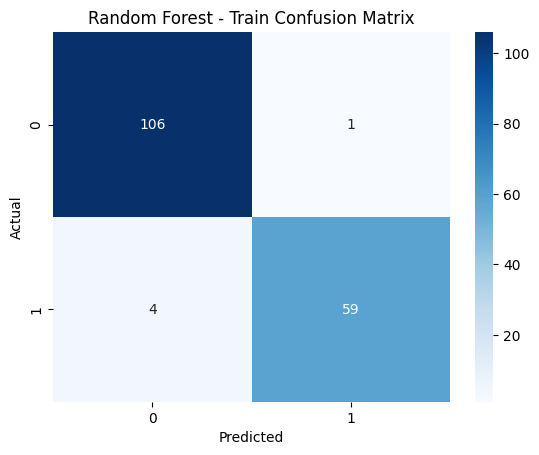

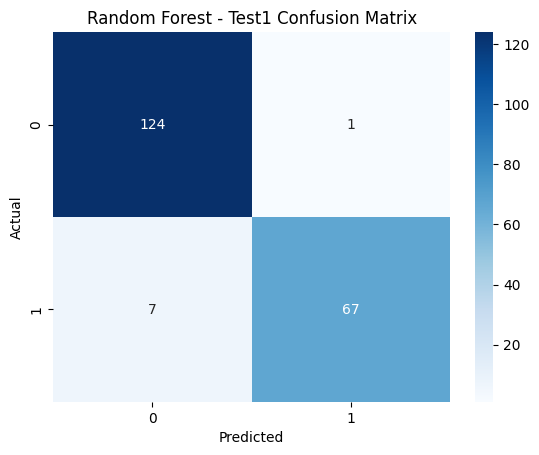

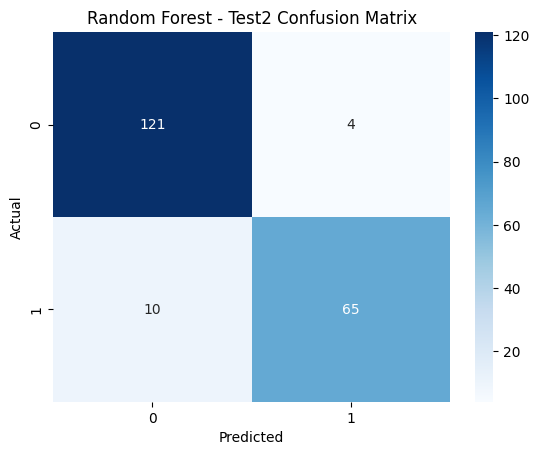


📊 Confusion Matrices for XGBoost:


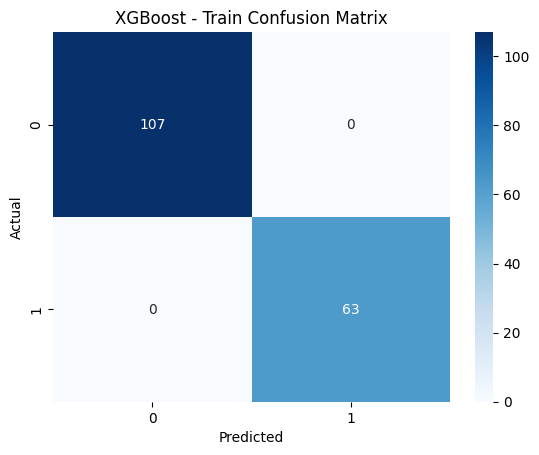

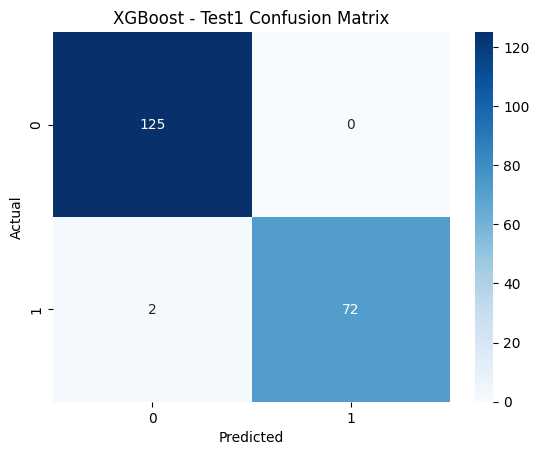

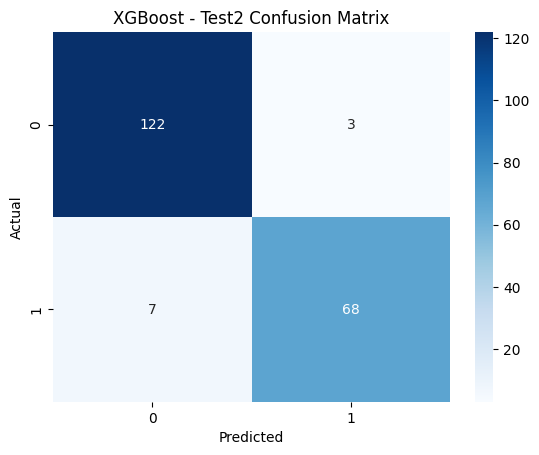

In [44]:
def plot_conf(title, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

for model_name, preds in [
    ("Decision Tree", (y_pred_train, y_pred_test1, y_pred_test2)),
    ("Bagging", (bag_pred_train, bag_pred_test1, bag_pred_test2)),
    ("Random Forest", (rf_pred_train, rf_pred_test1, rf_pred_test2)),
    ("XGBoost", (xgb_pred_train, xgb_pred_test1, xgb_pred_test2)),
]:
    print(f"\n📊 Confusion Matrices for {model_name}:")
    plot_conf(f"{model_name} - Train Confusion Matrix", y_train, preds[0])
    plot_conf(f"{model_name} - Test1 Confusion Matrix", y_test1, preds[1])
    plot_conf(f"{model_name} - Test2 Confusion Matrix", y_test2, preds[2])


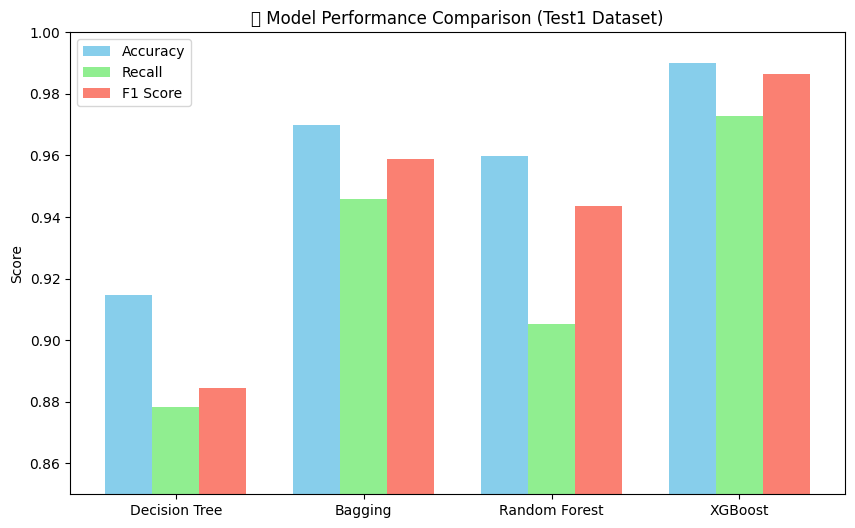

In [45]:
models = results_df["Model"]
acc_scores = results_df["Test1_Accuracy"]
recall_scores = results_df["Test1_Recall"]
f1_scores = results_df["Test1_F1"]

plt.figure(figsize=(10, 6))
bar_width = 0.25
x = np.arange(len(models))
plt.bar(x - bar_width, acc_scores, width=bar_width, label='Accuracy', color='skyblue')
plt.bar(x, recall_scores, width=bar_width, label='Recall', color='lightgreen')
plt.bar(x + bar_width, f1_scores, width=bar_width, label='F1 Score', color='salmon')
plt.xticks(x, models)
plt.title("📈 Model Performance Comparison (Test1 Dataset)")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.legend()
plt.show()
